# CDC Diabetes Health Indicators — EDA

**Primary sample:** full_clean_v1 (all 253,680 supplied records).
**Sensitivity sample:** unique_profile_v1 (complete-row deduplication).

This cleaned notebook preserves the original EDA sequence and observations,
removes unrelated Heart Disease examples and repeated downloads, and adds the
project-required correlation and duplicate-sensitivity analysis.

The project defines target 1 as prediabetes or diabetes. This agrees with the
imported dictionary; the original BRFSS preprocessing was not independently audited.
Charts use Category 0/1 consistently. The raw dataset is never silently deduplicated.

Run all cells from top to bottom. If the raw CSV is absent, the first code cell
downloads public UCI dataset 891 and verifies it. The CSV remains local.


## 1. Load and Preview the Dataset

Loading the CDC Diabetes Health Indicators dataset from the UCI repository.
Combine the input features (`X`) and diabetes status target (`y`) into
one table called `df`.

Displayed the first five rows to preview the dataset.

In [ ]:
from pathlib import Path
import os
import sys
import pandas as pd

# Run from the repository root or its notebooks folder.
ROOT = Path.cwd()
if not (ROOT / "src").is_dir() and (ROOT.parent / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Open this notebook inside the project repository.")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache" / "matplotlib"))
import matplotlib.pyplot as plt

from src.common.config import FEATURE_COLUMNS, EXPECTED_COLUMNS, VARIABLE_METADATA
from src.data.loader import load_dataset, download_uci_dataset
from src.data.validation import validate_dataset
from src.data.preprocessing import prepare_analysis_data

CSV_PATH = ROOT / "data" / "raw" / "cdc_diabetes.csv"
download_uci_dataset(str(CSV_PATH))

raw = load_dataset(str(CSV_PATH))
checks = validate_dataset(raw, EXPECTED_COLUMNS, "Diabetes_binary")
if not checks["is_valid"] or not checks["matches_reference"]:
    raise ValueError("Source CSV failed schema/reference verification.")
df = prepare_analysis_data(raw, "Diabetes_binary", FEATURE_COLUMNS)
X = df[FEATURE_COLUMNS]
y = df[["Diabetes_binary"]]
print("Dataset variant:", df.attrs["dataset_variant"])
display(df.head())


Dataset variant: full_clean_v1


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


## 2. Examine the Dataset Structure

Checking the number of rows and columns, column names, data types, and
non-missing values.

Each row represents a survey respondent. Some numerical columns contain
category codes rather than measured quantities.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 253680
Number of columns: 22
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  

## 3. Understand the Variables

Display the data dictionary to understand each column's meaning and role.

Check the definitions of the target variable and category codes,
especially Age, Sex, Education, and Income, before interpreting them.

In [3]:
dictionary = pd.DataFrame([
    {"name": column, **VARIABLE_METADATA[column]}
    for column in EXPECTED_COLUMNS
])
with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(dictionary[["name", "role", "type", "description", "category_labels", "unit"]])


,name,role,type,description,category_labels,unit
0,HighBP,feature,binary,Reported high blood pressure.,"{0: 'No', 1: 'Yes'}",NaN
1,HighChol,feature,binary,Reported high cholesterol.,"{0: 'No', 1: 'Yes'}",NaN
2,CholCheck,feature,binary,Cholesterol checked within five years.,"{0: 'No', 1: 'Yes'}",NaN
3,BMI,feature,continuous,Recorded BMI; observed range 12–98 is not a clinical validity threshold.,None,BMI units
4,Smoker,feature,binary,At least 100 cigarettes smoked in lifetime; not necessarily current smoking.,"{0: 'No', 1: 'Yes'}",NaN
5,Stroke,feature,binary,Ever told respondent had a stroke.,"{0: 'No', 1: 'Yes'}",NaN
6,HeartDiseaseorAttack,feature,binary,Coronary heart disease or myocardial infarction.,"{0: 'No', 1: 'Yes'}",NaN
7,PhysActivity,feature,binary,"Activity in past 30 days, excluding work.","{0: 'No', 1: 'Yes'}",NaN
8,Fruits,feature,binary,Fruit consumed one or more times per day.,"{0: 'No', 1: 'Yes'}",NaN
9,Veggies,feature,binary,Vegetables consumed one or more times per day.,"{0: 'No', 1: 'Yes'}",NaN


## 4. Check Data Quality

Count missing values, calculate their percentage, and check the number
of distinct values in each column. Also count repeated rows.

Repeated rows are not automatically errors: different respondents may
have identical answers. Investigate them before deciding whether to
remove any records.

In [4]:
quality_check = pd.DataFrame({
    "data_type": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "unique_values": df.nunique()
})

display(quality_check)

print("Repeated rows beyond the first occurrence:", df.duplicated().sum())

,data_type,missing_count,missing_percent,unique_values
HighBP,int64,0,0.0,2
HighChol,int64,0,0.0,2
CholCheck,int64,0,0.0,2
BMI,int64,0,0.0,84
Smoker,int64,0,0.0,2
Stroke,int64,0,0.0,2
HeartDiseaseorAttack,int64,0,0.0,2
PhysActivity,int64,0,0.0,2
Fruits,int64,0,0.0,2
Veggies,int64,0,0.0,2


Repeated rows beyond the first occurrence: 24206


## 5. Examine the Target Distribution

Count the respondents in each target category and calculate their
percentage of the dataset.

This helps identify class imbalance, where one category contains many
more respondents than another. These percentages describe this sample,
not necessarily the wider population.

In [5]:
target = y.columns[0]
print("Target column:", target)

target_summary = (
    df[target]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("target_value")
    .to_frame("respondents")
)

target_summary["percent"] = (
    target_summary["respondents"] / len(df) * 100
).round(2)

display(target_summary)

Target column: Diabetes_binary


,respondents,percent
target_value,,
0,218334,86.07
1,35346,13.93


## 6. Visualize the Target Distribution

Create a bar chart showing the number of respondents in each diabetes
target category. Add percentages to show each category's share of the dataset.

This helps identify class imbalance, which is important when interpreting
results and evaluating models later.

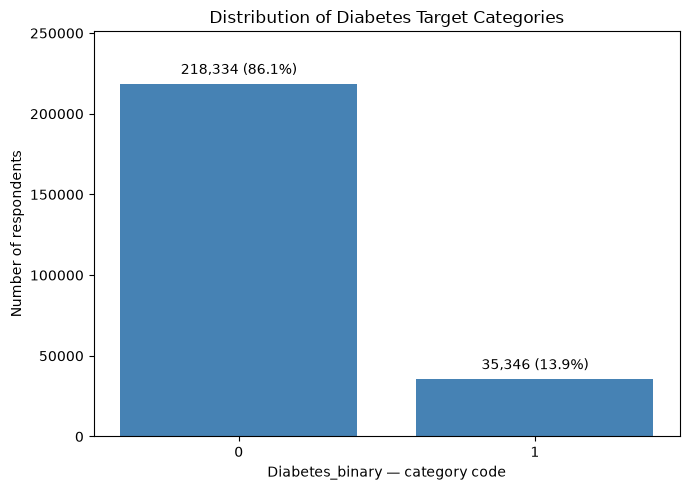

In [6]:
import matplotlib.pyplot as plt

# Count respondents in each target category
target = y.columns[0]
counts = df[target].value_counts().sort_index()
percentages = counts / counts.sum() * 100

# Keep the original codes until their meanings are confirmed
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    counts.index.astype(str),
    counts.values,
    color="steelblue"
)

# Add counts and percentages above each bar
labels = [
    f"{count:,} ({percent:.1f}%)"
    for count, percent in zip(counts.values, percentages.values)
]
ax.bar_label(bars, labels=labels, padding=5)

ax.set_title("Distribution of Diabetes Target Categories")
ax.set_xlabel(f"{target} — category code")
ax.set_ylabel("Number of respondents")
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

## 7. Explore the BMI Distribution

Examine summary statistics and a histogram of Body Mass Index (BMI).

The summary shows typical values and the overall range. The histogram
shows where values are concentrated and whether the distribution has
a long tail. Unusually high or low values should be investigated before
deciding whether any records need to be removed.

,BMI
count,253680.00
mean,28.38
std,6.61
min,12.00
25%,24.00
50%,27.00
75%,31.00
max,98.00


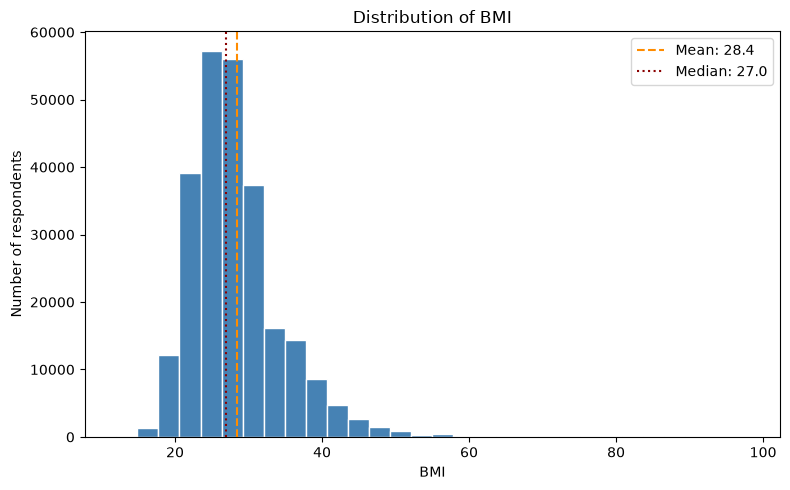

In [7]:
# Summary statistics for BMI
display(df["BMI"].describe().round(2).to_frame("BMI"))

# Histogram of BMI
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df["BMI"], bins=30, color="steelblue", edgecolor="white")

ax.axvline(
    df["BMI"].mean(),
    color="darkorange",
    linestyle="--",
    label=f"Mean: {df['BMI'].mean():.1f}"
)

ax.axvline(
    df["BMI"].median(),
    color="darkred",
    linestyle=":",
    label=f"Median: {df['BMI'].median():.1f}"
)

ax.set_title("Distribution of BMI")
ax.set_xlabel("BMI")
ax.set_ylabel("Number of respondents")
ax.legend()

plt.tight_layout()
plt.show()

### Observation: BMI Distribution

BMI has a right-skewed distribution, with most observations concentrated
around the twenties and low thirties and a long tail toward higher values.

The mean BMI is 28.38, while the median is 27. The middle 50% of
observations lie between 24 and 31.

BMI ranges from 12 to 98. Extreme values will be investigated before
making any decision to remove or modify them.

## 8. Investigate Potential BMI Outliers

The interquartile range (IQR) measures the spread of the middle 50%
of values: IQR = Q3 − Q1.

Flag values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR for review.
These flags identify statistically unusual values, not necessarily errors.
No records are removed in this step.

In [8]:
q1 = df["BMI"].quantile(0.25)
q3 = df["BMI"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

flagged = (df["BMI"] < lower_bound) | (df["BMI"] > upper_bound)

print(f"IQR: {iqr:.1f}")
print(f"Lower boundary: {lower_bound:.1f}")
print(f"Upper boundary: {upper_bound:.1f}")
print(f"Flagged observations: {flagged.sum():,}")
print(f"Percentage flagged: {flagged.mean() * 100:.2f}%")

# Inspect the frequency of the lowest and highest recorded BMI values
bmi_counts = df["BMI"].value_counts().sort_index()

print("\nLowest 10 distinct BMI values:")
display(bmi_counts.head(10).to_frame("Respondents"))

print("\nHighest 10 distinct BMI values:")
display(bmi_counts.tail(10).to_frame("Respondents"))

IQR: 7.0
Lower boundary: 13.5
Upper boundary: 41.5
Flagged observations: 9,847
Percentage flagged: 3.88%

Lowest 10 distinct BMI values:


,Respondents
BMI,
12,6
13,21
14,41
15,132
16,348
17,776
18,1803
19,3968
20,6327



Highest 10 distinct BMI values:


,Respondents
BMI,
86,1
87,61
88,2
89,28
90,1
91,1
92,32
95,12
96,1


### Observation: Potential BMI Outliers

Using the 1.5 × IQR rule, 9,847 observations (3.88% of the dataset)
were flagged outside the boundaries of 13.5 and 41.5.

There are 27 observations below the lower boundary and 9,820 above
the upper boundary, consistent with the right-skewed BMI distribution.

These observations are retained for now because statistical outlier
flags alone do not establish data errors. The extreme values require
further verification against the source documentation.

## 9. Compare BMI Across Target Categories

Compare BMI counts, means, medians, and quartiles for each target category.

A box plot shows the median and middle 50% of values for each group,
with points beyond the whiskers marking potential outliers.

The comparison describes an association in this sample; it cannot
establish that one variable causes the other.

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,,,,,,,,
0,218334.0,27.81,6.29,12.0,24.0,27.0,31.0,98.0
1,35346.0,31.94,7.36,13.0,27.0,31.0,35.0,98.0


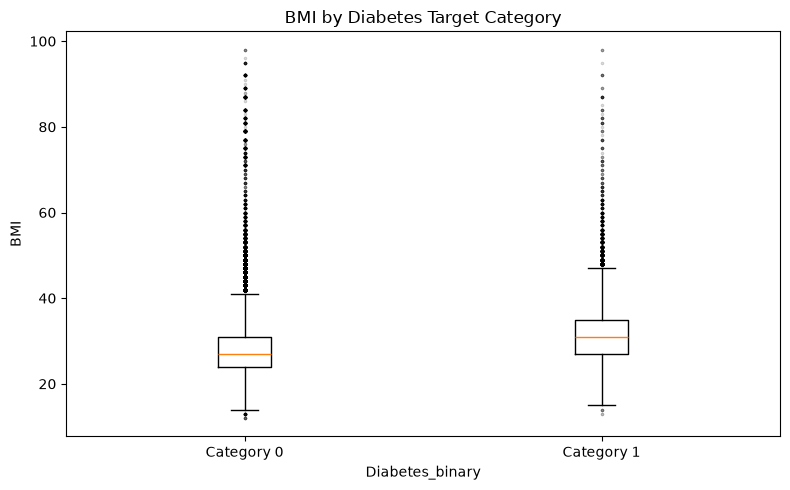

In [9]:
# Compare summary statistics across target categories
bmi_summary = (
    df.groupby("Diabetes_binary")["BMI"]
    .describe()
    .round(2)
)

display(bmi_summary)

# Compare distributions without removing any observations
groups = [
    df.loc[df["Diabetes_binary"] == 0, "BMI"],
    df.loc[df["Diabetes_binary"] == 1, "BMI"]
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    groups,
    showfliers=True,
    flierprops={
        "marker": ".",
        "markersize": 3,
        "alpha": 0.2
    }
)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Category 0", "Category 1"])
ax.set_title("BMI by Diabetes Target Category")
ax.set_xlabel("Diabetes_binary")
ax.set_ylabel("BMI")

plt.tight_layout()
plt.show()

## 10. Explore Reported Mental and Physical Health Days

Examine MentHlth and PhysHlth, which record the number of days
during the past 30 days when respondents reported that their mental
or physical health was not good.

Display summary statistics and the frequency of each recorded value.
Check for missing values and values outside the expected 0–30 range.

These are counts of days, so zero should not automatically be treated
as missing data.

,MentHlth,PhysHlth
count,253680.00,253680.00
mean,3.18,4.24
std,7.41,8.72
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,2.00,3.00
max,30.00,30.00



MentHlth
Missing values: 0
Values outside 0–30: 0
Respondents reporting 0 days: 175680
Respondents reporting 30 days: 12088

PhysHlth
Missing values: 0
Values outside 0–30: 0
Respondents reporting 0 days: 160052
Respondents reporting 30 days: 19400


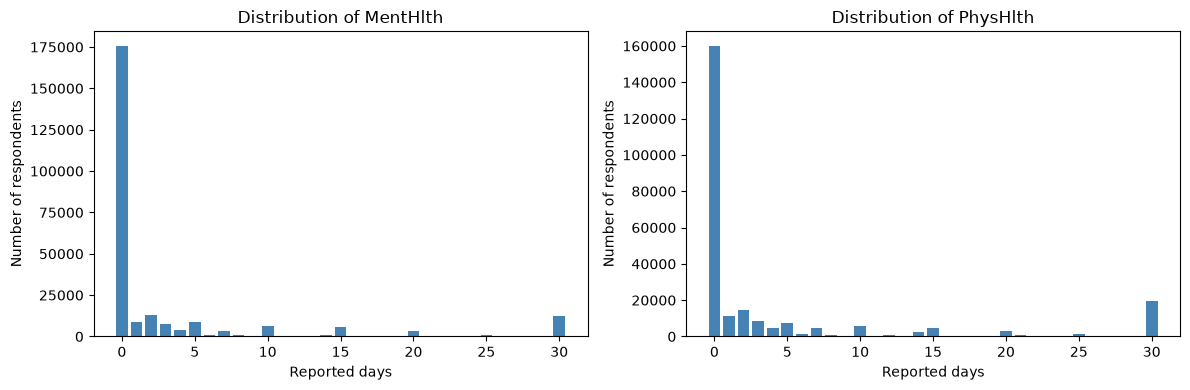

In [10]:
health_columns = ["MentHlth", "PhysHlth"]

display(df[health_columns].describe().round(2))

# Check the recorded values without changing them
for column in health_columns:
    values = df[column]

    print(f"\n{column}")
    print("Missing values:", values.isna().sum())
    print(
        "Values outside 0–30:",
        (values.notna() & ~values.between(0, 30)).sum()
    )
    print("Respondents reporting 0 days:", (values == 0).sum())
    print("Respondents reporting 30 days:", (values == 30).sum())

# Plot the frequency of each observed value
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, column in zip(axes, health_columns):
    counts = df[column].value_counts().sort_index()

    ax.bar(counts.index, counts.values, color="steelblue")
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel("Reported days")
    ax.set_ylabel("Number of respondents")
    ax.set_xticks(range(0, 31, 5))

plt.tight_layout()
plt.show()

## 11. Compare Health Days Across Target Categories

Compare the mean and median number of reported poor-health days
across the two target categories.

Also compare the percentage within each category reporting at least
one poor-health day and the percentage reporting all 30 days.

These comparisons describe associations in the sample, not causation.

Diabetes_binary,0,1
respondents,218334.00,35346.00
mental_mean,2.98,4.46
mental_median,0.00,0.00
mental_any_percent,30.26,33.79
mental_30_percent,4.27,7.83
physical_mean,3.64,7.95
physical_median,0.00,1.00
physical_any_percent,34.36,52.64
physical_30_percent,6.26,16.20


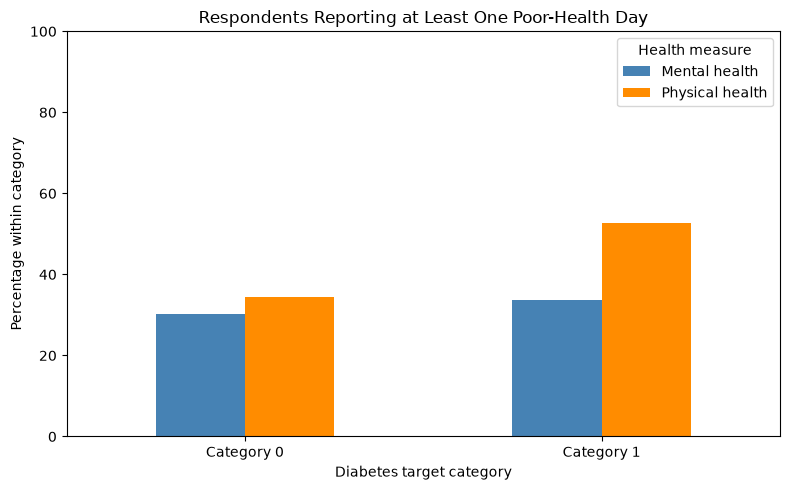

In [11]:
health_by_target = df.groupby("Diabetes_binary").agg(
    respondents=("MentHlth", "size"),
    mental_mean=("MentHlth", "mean"),
    mental_median=("MentHlth", "median"),
    mental_any_percent=("MentHlth", lambda s: s.gt(0).mean() * 100),
    mental_30_percent=("MentHlth", lambda s: s.eq(30).mean() * 100),
    physical_mean=("PhysHlth", "mean"),
    physical_median=("PhysHlth", "median"),
    physical_any_percent=("PhysHlth", lambda s: s.gt(0).mean() * 100),
    physical_30_percent=("PhysHlth", lambda s: s.eq(30).mean() * 100)
)

# Transpose so the measures appear as easy-to-read rows
display(health_by_target.round(2).T)

plot_data = health_by_target[
    ["mental_any_percent", "physical_any_percent"]
].copy()

plot_data.columns = ["Mental health", "Physical health"]
plot_data.index = [
    f"Category {code}" for code in plot_data.index
]

ax = plot_data.plot.bar(
    figsize=(8, 5),
    color=["steelblue", "darkorange"],
    rot=0
)

ax.set_title("Respondents Reporting at Least One Poor-Health Day")
ax.set_xlabel("Diabetes target category")
ax.set_ylabel("Percentage within category")
ax.set_ylim(0, 100)
ax.legend(title="Health measure")

plt.tight_layout()
plt.show()

### Observation: Health Days Across Target Categories

Category 1 reports more poor-health days on average than category 0.
The difference is larger for physical health.

At least one poor physical-health day was reported by 52.64% of category 1
and 34.36% of category 0, a difference of 18.28 percentage points.
Mean poor physical-health days were 7.95 and 3.64, respectively.

For mental health, 33.79% of category 1 and 30.26% of category 0 reported
at least one poor-health day. Mean poor mental-health days were 4.46
and 2.98, respectively.

Reporting poor physical health on all 30 days was also more common
in category 1 (16.20%) than category 0 (6.26%).

These comparisons describe associations in this sample. They do not
account for age or other factors and do not establish causation.

## 12. Explore Age Groups and Target Distribution

Check the observed age-group codes and count respondents in each group.
Then calculate the percentage belonging to target category 1 within
each age group.

Using percentages within each group allows comparisons between age
groups of different sizes. Age codes are kept in numerical order;
they represent age categories, not individual ages in years.

Missing age values: 0
Unexpected age codes: 0


,respondents,category_1_count,category_1_percent
Age,,,
1,5700,78,1.37
2,7598,140,1.84
3,11123,314,2.82
4,13823,626,4.53
5,16157,1051,6.50
6,19819,1742,8.79
7,26314,3088,11.74
8,30832,4263,13.83
9,33244,5733,17.25


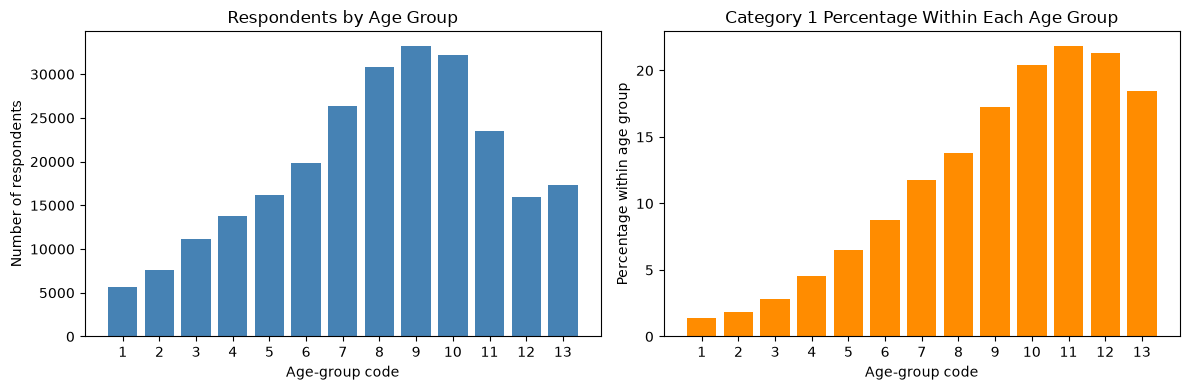

In [12]:
# Check for missing or unexpected age codes
print("Missing age values:", df["Age"].isna().sum())

unexpected_age = (
    df["Age"].notna()
    & ~df["Age"].isin(range(1, 14))
)
print("Unexpected age codes:", unexpected_age.sum())

# Summarize each observed age group
age_summary = (
    df.groupby("Age")["Diabetes_binary"]
    .agg(
        respondents="size",
        category_1_count=lambda s: s.eq(1).sum()
    )
    .sort_index()
)

age_summary["category_1_percent"] = (
    age_summary["category_1_count"]
    / age_summary["respondents"] * 100
)

display(age_summary.round(2))

# Show group sizes and within-group percentages
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    age_summary.index.astype(str),
    age_summary["respondents"],
    color="steelblue"
)
axes[0].set_title("Respondents by Age Group")
axes[0].set_xlabel("Age-group code")
axes[0].set_ylabel("Number of respondents")

axes[1].bar(
    age_summary.index.astype(str),
    age_summary["category_1_percent"],
    color="darkorange"
)
axes[1].set_title("Category 1 Percentage Within Each Age Group")
axes[1].set_xlabel("Age-group code")
axes[1].set_ylabel("Percentage within age group")

plt.tight_layout()
plt.show()

### Observation: Age Groups and Target Category

All age codes fall within the expected range of 1–13, with no missing
age values.

The percentage of respondents in target category 1 increases from
1.37% in age group 1 to a peak of 21.85% in group 11. It then declines
to 21.30% in group 12 and 18.48% in group 13.

Group 9 contains the largest number of respondents, whereas group 11
has the highest percentage belonging to category 1. This demonstrates
why within-group percentages are useful when group sizes differ.

The pattern suggests an association between age group and target
category in this sample. It does not establish causation or explain
the decline in the oldest groups.

## 13. Compare Selected Health Indicators with the Target

For high blood pressure, high cholesterol, and physical activity,
check that the recorded values are 0 or 1.

For each indicator, compare the percentage of respondents in target
category 1 between the No and Yes groups. Show group counts alongside
percentages to make the size of each group clear.

These are separate, unadjusted comparisons. Other characteristics,
such as age, could contribute to the observed differences.


High blood pressure
Missing values: 0
Unexpected codes: 0


,respondents,category_1_count,category_1_percent
HighBP,,,
0,144851,8742,6.04
1,108829,26604,24.45



High cholesterol
Missing values: 0
Unexpected codes: 0


,respondents,category_1_count,category_1_percent
HighChol,,,
0,146089,11660,7.98
1,107591,23686,22.01



Physical activity
Missing values: 0
Unexpected codes: 0


,respondents,category_1_count,category_1_percent
PhysActivity,,,
0,61760,13059,21.14
1,191920,22287,11.61


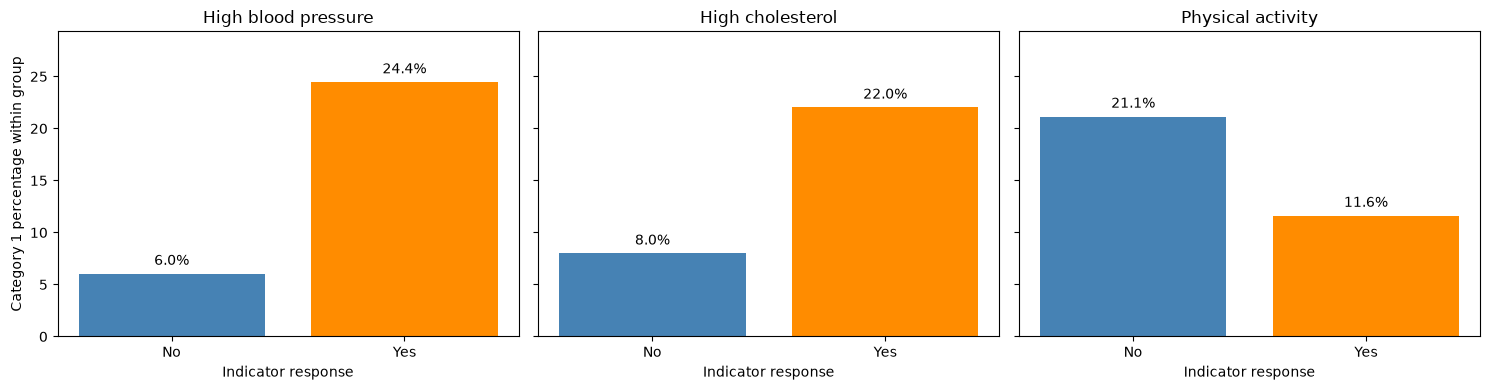

In [13]:
indicators = {
    "HighBP": "High blood pressure",
    "HighChol": "High cholesterol",
    "PhysActivity": "Physical activity"
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (column, title) in zip(axes, indicators.items()):
    values = df[column]

    print(f"\n{title}")
    print("Missing values:", values.isna().sum())
    print(
        "Unexpected codes:",
        (values.notna() & ~values.isin([0, 1])).sum()
    )

    summary = (
        df.groupby(column)["Diabetes_binary"]
        .agg(
            respondents="size",
            category_1_count=lambda s: s.eq(1).sum()
        )
        .sort_index()
    )

    summary["category_1_percent"] = (
        summary["category_1_count"]
        / summary["respondents"] * 100
    )

    display(summary.round(2))

    # Plot the expected No/Yes codes
    plot_values = summary["category_1_percent"].reindex([0, 1])

    bars = ax.bar(
        ["No", "Yes"],
        plot_values,
        color=["steelblue", "darkorange"]
    )

    ax.bar_label(bars, fmt="%.1f%%", padding=4)
    ax.set_title(title)
    ax.set_xlabel("Indicator response")
    ax.margins(y=0.2)

axes[0].set_ylabel("Category 1 percentage within group")

plt.tight_layout()
plt.show()

## 14. Examine Demographic Categories

Check Sex, Education, and Income for missing values and unexpected codes.

For each variable, show the number of respondents and the percentage
belonging to target category 1 within each category.

Sex is a categorical variable. Education and Income contain ordered
category codes, not years of education or exact income amounts.
Interpret the codes using the data dictionary.


Sex
Missing values: 0
Unexpected codes: 0


,respondents,category_1_count,category_1_percent
Sex,,,
0,141974,18411,12.97
1,111706,16935,15.16



Education
Missing values: 0
Unexpected codes: 0


,respondents,category_1_count,category_1_percent
Education,,,
1,174,47,27.01
2,4043,1183,29.26
3,9478,2296,24.22
4,62750,11066,17.64
5,69910,10354,14.81
6,107325,10400,9.69



Income


Missing values: 0
Unexpected codes: 0


,respondents,category_1_count,category_1_percent
Income,,,
1,9811,2383,24.29
2,11783,3086,26.19
3,15994,3568,22.31
4,20135,4054,20.13
5,25883,4504,17.40
6,36470,5291,14.51
7,43219,5265,12.18
8,90385,7195,7.96


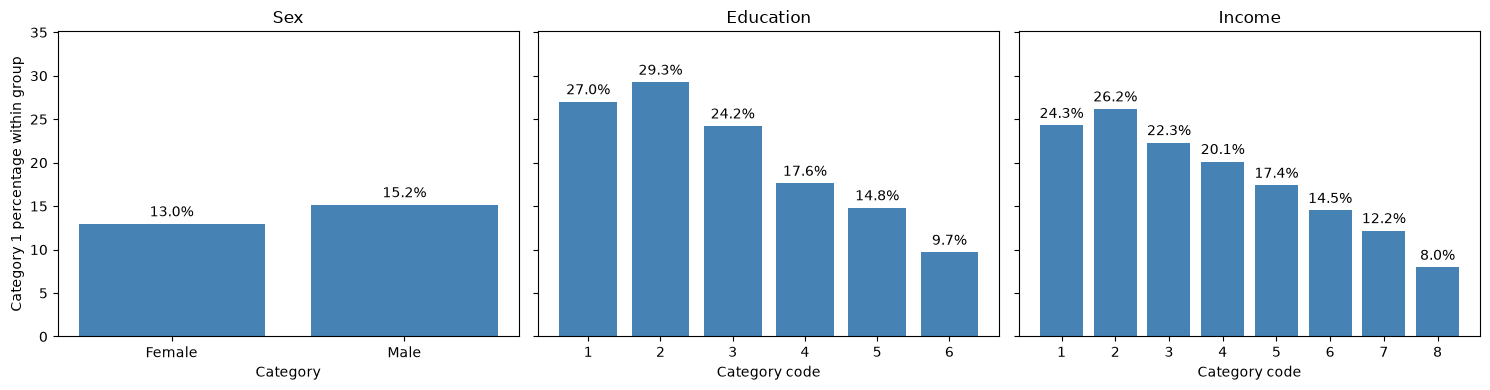

In [14]:
demographics = {
    "Sex": [0, 1],
    "Education": list(range(1, 7)),
    "Income": list(range(1, 9))
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (column, expected_codes) in zip(axes, demographics.items()):
    values = df[column]

    print(f"\n{column}")
    print("Missing values:", values.isna().sum())
    print(
        "Unexpected codes:",
        (values.notna() & ~values.isin(expected_codes)).sum()
    )

    summary = (
        df.groupby(column)["Diabetes_binary"]
        .agg(
            respondents="size",
            category_1_count=lambda s: s.eq(1).sum()
        )
        .sort_index()
    )

    summary["category_1_percent"] = (
        summary["category_1_count"]
        / summary["respondents"] * 100
    )

    display(summary.round(2))

    # Use the Sex labels confirmed in your data dictionary
    if column == "Sex":
        labels = [
            {0: "Female", 1: "Male"}.get(code, str(code))
            for code in summary.index
        ]
    else:
        labels = summary.index.astype(str)

    bars = ax.bar(
        labels,
        summary["category_1_percent"],
        color="steelblue"
    )

    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_title(column)
    ax.set_xlabel("Category" if column == "Sex" else "Category code")
    ax.margins(y=0.2)

axes[0].set_ylabel("Category 1 percentage within group")

plt.tight_layout()
plt.show()

### Observation: Sex, Education, and Income

The percentage belonging to target category 1 is 15.16% among males
and 12.97% among females, a difference of 2.19 percentage points.

For education, the percentage peaks in category 2 at 29.26% and then
decreases across successive categories to 9.69% in category 6.
Category 1 contains only 174 respondents, so its percentage should
be interpreted cautiously.

For income, the percentage peaks in category 2 at 26.19% and then
decreases to 7.96% in category 8.

Higher education and income categories are generally associated with
lower category 1 percentages in this sample. These are unadjusted
associations and may reflect differences in age or other characteristics.
They do not establish causation.

No missing values or unexpected codes were found in these variables.

## 15. Validate the Remaining Categorical Features

Check the remaining binary features for values other than 0 and 1.
Check GenHlth, an ordered general-health rating, for codes outside 1–5.

Summarize missing values, unexpected codes, and observed values.
This checks code validity; it does not prove that every response is accurate.
No records are changed or removed.

In [15]:
remaining_binary = [
    "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack",
    "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk", "Diabetes_binary"
]

expected_values = {
    column: [0, 1] for column in remaining_binary
}
expected_values["GenHlth"] = [1, 2, 3, 4, 5]

checks = []

for column, allowed in expected_values.items():
    values = df[column]
    unexpected = values.notna() & ~values.isin(allowed)

    checks.append({
        "Column": column,
        "Missing values": values.isna().sum(),
        "Unexpected codes": unexpected.sum(),
        "Observed values": sorted(values.dropna().unique().tolist())
    })

validation_summary = pd.DataFrame(checks).set_index("Column")
display(validation_summary)

,Missing values,Unexpected codes,Observed values
Column,,,
CholCheck,0,0,"[0, 1]"
Smoker,0,0,"[0, 1]"
Stroke,0,0,"[0, 1]"
HeartDiseaseorAttack,0,0,"[0, 1]"
Fruits,0,0,"[0, 1]"
Veggies,0,0,"[0, 1]"
HvyAlcoholConsump,0,0,"[0, 1]"
AnyHealthcare,0,0,"[0, 1]"
NoDocbcCost,0,0,"[0, 1]"


### Observation: Category Validation

All checked binary columns contain only the expected codes 0 and 1.
GenHlth contains only the expected codes 1–5.

No missing values or unexpected category codes were found.
No records were modified or removed based on these checks.

## 16. Summarize the Remaining Binary Features

For each feature, count the No and Yes responses and calculate the
percentage belonging to target category 1 within each response group.

Calculate the percentage-point difference as Yes minus No.
A positive difference means category 1 is more common in the Yes group;
a negative difference means it is less common.

These are descriptive, unadjusted comparisons, not causal effects.
Interpret each response using the feature's definition.

In [16]:
features = [
    "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack",
    "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk"
]

rows = []

for column in features:
    no_group = df.loc[df[column] == 0, "Diabetes_binary"]
    yes_group = df.loc[df[column] == 1, "Diabetes_binary"]

    no_percent = no_group.mean() * 100
    yes_percent = yes_group.mean() * 100

    rows.append({
        "Feature": column,
        "No respondents": len(no_group),
        "Yes respondents": len(yes_group),
        "Category 1 % — No": no_percent,
        "Category 1 % — Yes": yes_percent,
        "Difference (percentage points)": yes_percent - no_percent
    })

remaining_summary = pd.DataFrame(rows).set_index("Feature")

display(remaining_summary.round(2))

,No respondents,Yes respondents,Category 1 % — No,Category 1 % — Yes,Difference (percentage points)
Feature,,,,,
CholCheck,9470,244210,2.54,14.37,11.83
Smoker,141257,112423,12.06,16.29,4.24
Stroke,243388,10292,13.18,31.75,18.57
HeartDiseaseorAttack,229787,23893,11.95,32.97,21.02
Fruits,92782,160898,15.79,12.86,-2.93
Veggies,47839,205841,18.00,12.99,-5.01
HvyAlcoholConsump,239424,14256,14.42,5.84,-8.58
AnyHealthcare,12417,241263,11.45,14.06,2.61
NoDocbcCost,232326,21354,13.60,17.52,3.92


### Observation: Remaining Binary Features

Among these features, the largest positive percentage-point differences
are associated with reported heart disease or attack (+21.02),
difficulty walking (+20.21), and stroke (+18.57).

Respondents reporting daily fruit or vegetable consumption have lower
category 1 percentages than those reporting No, with differences of
−2.93 and −5.01 percentage points, respectively.

The heavy-alcohol-consumption group also has a lower category 1
percentage. This descriptive association does not demonstrate a
protective effect.

Cholesterol checks and healthcare coverage are associated with higher
category 1 percentages, but these results do not establish harmful
effects of screening or healthcare.

All comparisons are unadjusted. Differences in age, health status,
healthcare use, or behavior changes could contribute to these patterns.

## 17. Examine Self-Reported General Health

GenHlth is an ordered rating:
1 = Excellent, 2 = Very good, 3 = Good, 4 = Fair, 5 = Poor.

Count respondents in each rating and calculate the percentage belonging
to target category 1 within each group. Keep the ratings in their
meaningful order.

This describes the relationship between self-reported general health
and target category in the sample.

,respondents,category_1_count,category_1_percent
General health,,,
Excellent,45299,1140,2.52
Very good,89084,6381,7.16
Good,75646,13457,17.79
Fair,31570,9790,31.01
Poor,12081,4578,37.89


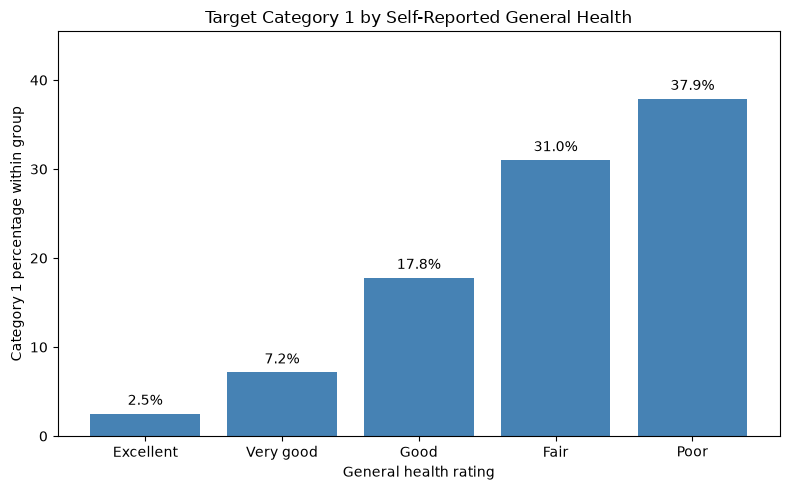

In [17]:
health_labels = {
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor"
}

general_health_summary = (
    df.groupby("GenHlth")["Diabetes_binary"]
    .agg(
        respondents="size",
        category_1_count="sum"
    )
    .reindex([1, 2, 3, 4, 5])
)

general_health_summary["category_1_percent"] = (
    general_health_summary["category_1_count"]
    / general_health_summary["respondents"] * 100
)

general_health_summary.index = (
    general_health_summary.index.map(health_labels)
)
general_health_summary.index.name = "General health"

display(general_health_summary.round(2))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    general_health_summary.index,
    general_health_summary["category_1_percent"],
    color="steelblue"
)

ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_title("Target Category 1 by Self-Reported General Health")
ax.set_xlabel("General health rating")
ax.set_ylabel("Category 1 percentage within group")
ax.margins(y=0.2)

plt.tight_layout()
plt.show()

### Observation: Self-Reported General Health

The percentage belonging to target category 1 increases consistently
as self-reported general health worsens:

- Excellent: 2.52%
- Very good: 7.16%
- Good: 17.79%
- Fair: 31.01%
- Poor: 37.89%

The difference between the Poor and Excellent groups is 35.37
percentage points.

This shows an association between poorer self-reported general health
and target category 1 in this sample. The comparison is unadjusted
and does not establish causation or the timing of these conditions.

## 18. Examine Repeated Records

Count repeated rows across all 21 features and the target.

Distinguish between:
- Extra occurrences beyond the first copy of each repeated pattern.
- All rows belonging to a repeated pattern, including the first copy.

Identical answers do not necessarily represent the same respondent.
Because many features use a small number of category codes, different
people may have identical recorded profiles. No rows are removed here.

In [18]:
# Use only the original features and target, excluding any added labels
original_columns = list(X.columns) + list(y.columns)
records = df[original_columns]

extra_copies = records.duplicated()
all_repeated = records.duplicated(keep=False)

print("Total rows:", len(records))
print("Distinct feature-and-target patterns:", len(records.drop_duplicates()))

print(
    "Extra occurrences beyond the first:",
    f"{extra_copies.sum():,}"
)

print(
    "Percentage of extra occurrences:",
    f"{extra_copies.mean() * 100:.2f}%"
)

print(
    "All rows belonging to repeated patterns:",
    f"{all_repeated.sum():,}"
)

# Preview repeated patterns without changing the dataset
display(records.loc[all_repeated].head(10))

Total rows: 253680
Distinct feature-and-target patterns: 229474
Extra occurrences beyond the first: 24,206
Percentage of extra occurrences: 9.54%
All rows belonging to repeated patterns: 35,575


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
5,1,1,1,25,1,0,0,1,1,1,...,0,2,0,2,0,1,10,6,8,0
25,0,0,1,32,0,0,0,1,1,1,...,0,2,0,0,0,0,5,6,8,0
29,0,1,1,31,1,0,0,1,1,1,...,0,1,0,0,0,1,12,6,8,0
44,0,1,1,31,1,0,0,0,1,1,...,0,2,0,0,0,0,8,5,8,0
52,1,1,1,27,1,0,0,0,0,1,...,0,5,0,30,1,0,10,4,5,1
53,0,0,1,31,0,0,0,1,0,1,...,0,2,0,0,0,0,10,5,6,0
57,0,1,1,24,1,0,0,1,1,1,...,0,1,0,0,0,0,10,6,8,0
70,1,1,1,27,1,0,0,1,0,1,...,0,2,0,0,0,1,12,5,5,0
80,1,0,1,28,0,0,0,1,0,1,...,0,2,0,0,0,1,7,6,8,0
113,1,0,1,27,0,0,0,1,1,1,...,0,3,0,0,0,1,8,6,8,0


### Observation: Repeated Records

The dataset contains 253,680 rows and 229,474 distinct combinations
of the 21 features and target.

There are 24,206 repeated occurrences beyond the first occurrence
of each pattern, representing 9.54% of all rows. Including first
occurrences, 35,575 rows belong to repeated patterns.

Identical feature-and-target combinations do not establish that the
records belong to the same person. Different respondents may share
the same recorded profile.

All rows are retained for the main exploratory analysis. Removing
records would require evidence of accidental duplication or a
documented alternative analysis.

## 19. Variable Definitions and Readable Labels

Age, Education, and Income are ordered categories rather than exact numerical measurements. Their labels are based on the CDC BRFSS codebook and the imported variable descriptions.

Income represents annual household income in US dollars. Sex is coded 0 = Female and 1 = Male in the imported data dictionary.

The imported dictionary describes Diabetes_binary as 0 = no diabetes and 1 = prediabetes or diabetes. The original binary-target preprocessing has not been independently verified; results therefore retain the labels Category 0 and Category 1.

The code below produces labeled tables and charts without changing the original data.

Reference: [CDC BRFSS 2015 Codebook](https://www.cdc.gov/brfss/annual_data/2015/pdf/CODEBOOK15_LLCP.pdf).

,respondents,category_1_count,category_1_percent
Age,,,
18–24,5700,78,1.37
25–29,7598,140,1.84
30–34,11123,314,2.82
35–39,13823,626,4.53
40–44,16157,1051,6.50
45–49,19819,1742,8.79
50–54,26314,3088,11.74
55–59,30832,4263,13.83
60–64,33244,5733,17.25


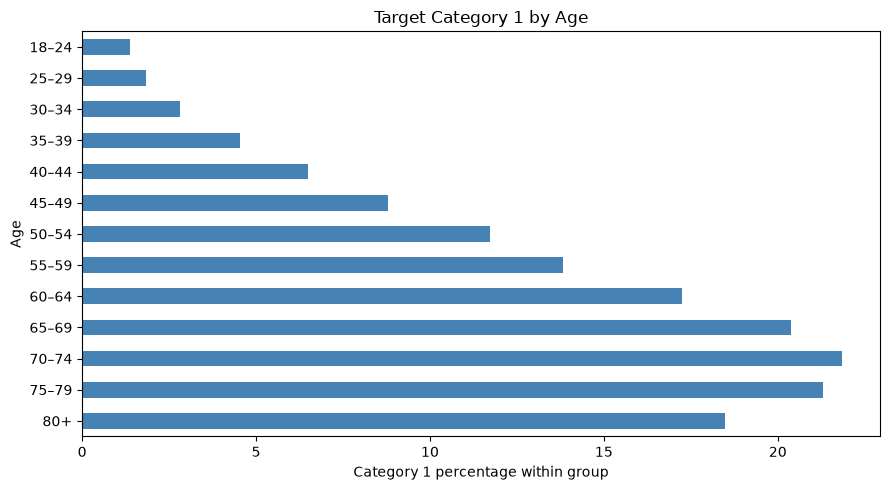

,respondents,category_1_count,category_1_percent
Education,,,
No schooling / kindergarten only,174,47,27.01
Grades 1–8,4043,1183,29.26
Grades 9–11,9478,2296,24.22
Grade 12 / GED,62750,11066,17.64
College 1–3 years,69910,10354,14.81
College 4+ years,107325,10400,9.69


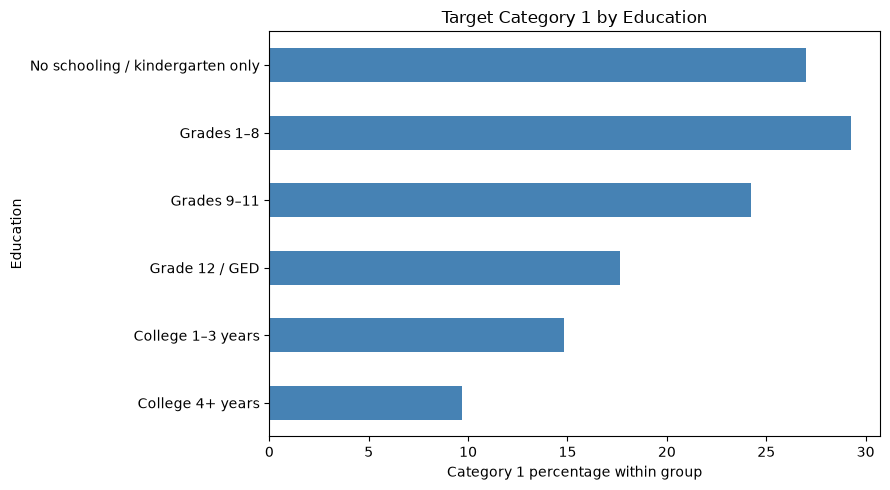

,respondents,category_1_count,category_1_percent
Income,,,
"Under USD 10,000",9811,2383,24.29
"USD 10,000–<15,000",11783,3086,26.19
"USD 15,000–<20,000",15994,3568,22.31
"USD 20,000–<25,000",20135,4054,20.13
"USD 25,000–<35,000",25883,4504,17.40
"USD 35,000–<50,000",36470,5291,14.51
"USD 50,000–<75,000",43219,5265,12.18
"USD 75,000+",90385,7195,7.96


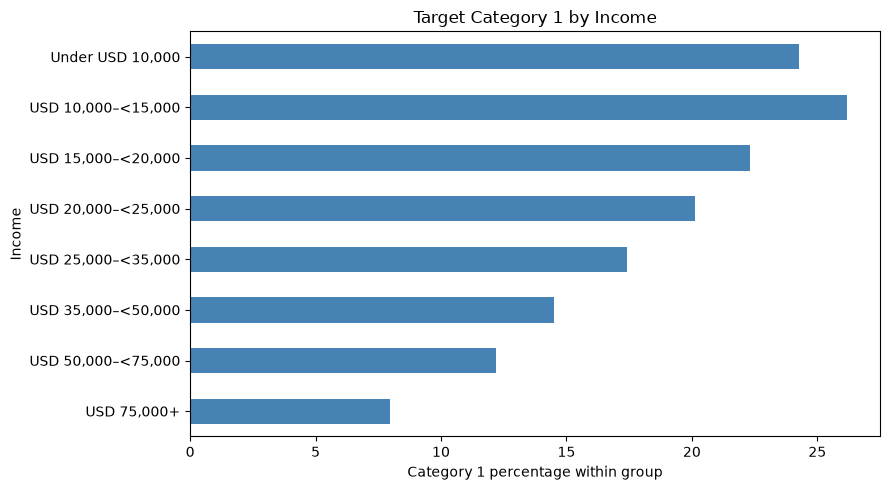

In [19]:
label_maps = {
    "Age": {
        1: "18–24", 2: "25–29", 3: "30–34", 4: "35–39",
        5: "40–44", 6: "45–49", 7: "50–54", 8: "55–59",
        9: "60–64", 10: "65–69", 11: "70–74",
        12: "75–79", 13: "80+"
    },
    "Education": {
        1: "No schooling / kindergarten only",
        2: "Grades 1–8",
        3: "Grades 9–11",
        4: "Grade 12 / GED",
        5: "College 1–3 years",
        6: "College 4+ years"
    },
    "Income": {
        1: "Under USD 10,000",
        2: "USD 10,000–<15,000",
        3: "USD 15,000–<20,000",
        4: "USD 20,000–<25,000",
        5: "USD 25,000–<35,000",
        6: "USD 35,000–<50,000",
        7: "USD 50,000–<75,000",
        8: "USD 75,000+"
    }
}

for column, mapping in label_maps.items():
    # Stop if any value cannot be assigned a documented label
    assert df[column].isin(mapping).all(), (
        f"Check missing or unexpected values in {column}"
    )

    summary = (
        df.groupby(column)["Diabetes_binary"]
        .agg(respondents="size", category_1_count="sum")
        .reindex(list(mapping))
    )

    summary["category_1_percent"] = (
        summary["category_1_count"]
        / summary["respondents"] * 100
    )

    summary.index = [mapping[code] for code in summary.index]
    summary.index.name = column

    display(summary.round(2))

    # Horizontal bars leave room for longer category labels
    ax = summary["category_1_percent"].plot.barh(
        figsize=(9, 5), color="steelblue"
    )

    ax.invert_yaxis()
    ax.set_title(f"Target Category 1 by {column}")
    ax.set_xlabel("Category 1 percentage within group")
    ax.set_ylabel(column)

    plt.tight_layout()
    plt.show()

## 20. Main EDA Findings

The dataset contains 253,680 respondents, 21 features, and one binary target.

- **Target imbalance:** Category 0 contains 86.1% of respondents and category 1 contains 13.9%. Accuracy alone would be insufficient for evaluating a predictive model.
- **BMI:** Category 1 has a higher mean BMI (31.94 versus 27.81) and median BMI (31 versus 27). The distributions overlap.
- **Age:** The category 1 percentage generally increases with age, reaching 21.85% among ages 70–74, before declining in the older groups.
- **Health indicators:** Category 1 is more common among respondents reporting high blood pressure, high cholesterol, stroke, heart disease or attack, and difficulty walking.
- **Physical activity:** Respondents reporting physical activity have a lower category 1 percentage (11.61%) than those reporting no activity (21.14%).
- **Health days:** Category 1 reports more poor physical-health days on average (7.95 versus 3.64).
- **General health:** The category 1 percentage increases from 2.52% among respondents reporting excellent health to 37.89% among those reporting poor health.
- **Education and income:** Higher categories generally have lower category 1 percentages, although neither pattern decreases at every step.
- **Sex:** The category 1 percentage is 15.16% among males and 12.97% among females.

These findings describe associations in the analyzed sample.

## 21. Limitations and Data-Handling Decisions

### Data quality and handling

- No pandas-recognized missing values were found. No missing-value imputation was performed.
- Checked categorical variables contained only expected codes.
- Mental and physical health-day values were within 0–30. Both endpoints were retained.
- The BMI IQR rule flagged 9,847 observations (3.88%). They were retained because statistical flags do not establish errors. The validity of extreme BMI values remains unresolved.
- There were 24,206 repeated occurrences beyond the first copy of each feature-and-target pattern (9.54%). All were retained because identical responses do not establish duplicate respondents.
- Labels were used for presentation without changing the original category codes.

### Interpretation limits

- Comparisons are descriptive and unadjusted. Age and other characteristics may contribute to observed differences.
- The analysis does not establish causation or whether one condition preceded another.
- Survey responses may contain reporting or recall errors.
- No survey weights or complex survey-design adjustments were applied. Percentages describe this sample and should not be presented as national population estimates.
- Small groups, such as education category 1 with 174 respondents, require cautious interpretation.
- The binary target's original preprocessing has not been independently verified; its imported definition is documented separately.
- Statistical significance and predictive performance were not assessed in this EDA.

**AI disclosure:** AI assistance was used for EDA guidance, explanations, code integration, and wording. Results were checked by executing the notebook and data/EDA tests.


## 22. Reusable Functions and Dataset-Variant Sensitivity

The earlier analysis uses full_clean_v1. Here we use the project functions to
construct unique_profile_v1 separately and compare important estimates.
Deduplication changes the represented sample and does not prove repeated respondents.


In [20]:
from src.analysis.eda import compare_dataset_variants

eda = compare_dataset_variants(raw)
variant_sizes = pd.DataFrame([
    {"dataset_variant": name, "respondents": len(bundle["data"]),
     "category_1_percent": bundle["data"]["Diabetes_binary"].mean() * 100}
    for name, bundle in eda["variants"].items()
])
display(variant_sizes.round(4))
display(eda["sensitivity"].round(4))


,dataset_variant,respondents,category_1_percent
0,full_clean_v1,253680,13.9333
1,unique_profile_v1,229474,15.2945


,feature,group,metric,estimate_full,n_full,estimate_unique,n_unique,change_unique_minus_full
0,Diabetes_binary,All,category_1_percent,13.9333,253680,15.2945,229474,1.3612
1,BMI,Target 0,mean,27.8058,218334,28.0959,194377,0.2901
2,BMI,Target 1,mean,31.9440,35346,31.9642,35097,0.0202
3,MentHlth,Target 0,mean,2.9780,218334,3.3323,194377,0.3542
4,MentHlth,Target 1,mean,4.4618,35346,4.4934,35097,0.0316
...,...,...,...,...,...,...,...,...
62,Income,"USD 20,000–<25,000",category_1_percent,20.1341,20135,20.2827,19953,0.1486
63,Income,"USD 25,000–<35,000",category_1_percent,17.4014,25883,17.7249,25326,0.3235
64,Income,"USD 35,000–<50,000",category_1_percent,14.5078,36470,15.0471,34957,0.5392
65,Income,"USD 50,000–<75,000",category_1_percent,12.1821,43219,13.0224,40131,0.8402


### Interpreting Sensitivity

The full sample remains the primary EDA sample. Compare estimate_full and
estimate_unique; change_unique_minus_full expresses their difference in the
metric's units (percentage points for percentages, original units for means).
Larger differences indicate findings that depend more on profile multiplicity.
This is a descriptive robustness check, not a statistical significance test.


## 23. Correlation Exploration

Use Spearman correlation to describe pairwise monotonic relationships among BMI,
health-day counts, ordered categories and the binary target. Category code order
is meaningful, but these codes are not exact ages or incomes. Sex is excluded
because its category order is arbitrary. The coefficients are unadjusted and
should not be interpreted as causal effects or predictive importance.


,BMI,MentHlth,PhysHlth,Age,Education,Income,GenHlth,Diabetes_binary
BMI,1.000,0.054,0.116,-0.025,-0.123,-0.092,0.257,0.226
MentHlth,0.054,1.000,0.308,-0.164,-0.054,-0.145,0.238,0.040
PhysHlth,0.116,0.308,1.000,0.052,-0.115,-0.218,0.452,0.157
Age,-0.025,-0.164,0.052,1.000,-0.101,-0.176,0.147,0.178
Education,-0.123,-0.054,-0.115,-0.101,1.000,0.452,-0.276,-0.120
Income,-0.092,-0.145,-0.218,-0.176,0.452,1.000,-0.354,-0.163
GenHlth,0.257,0.238,0.452,0.147,-0.276,-0.354,1.000,0.288
Diabetes_binary,0.226,0.040,0.157,0.178,-0.120,-0.163,0.288,1.000


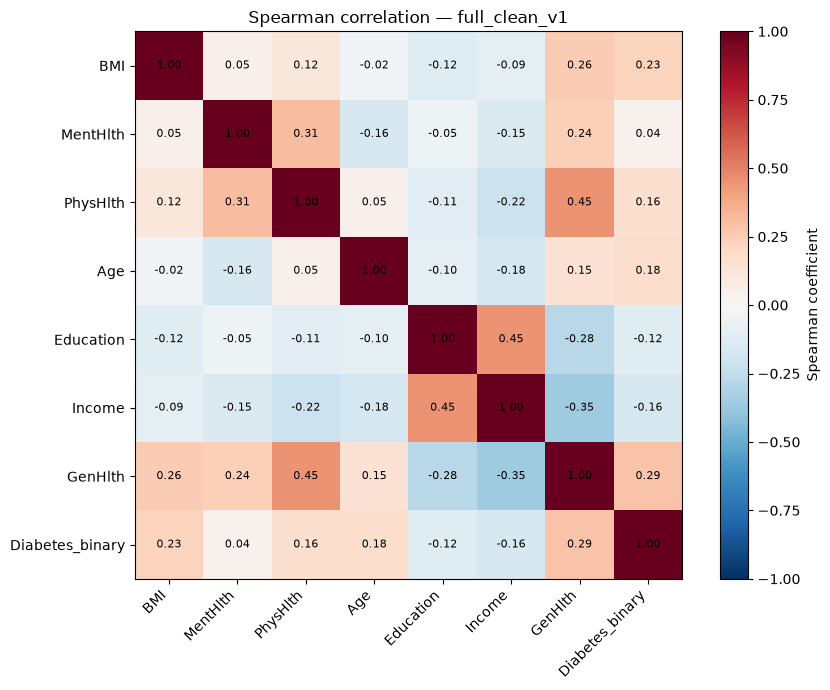

In [21]:
correlation = eda["variants"]["full_clean_v1"]["tables"]["spearman_correlation"]
display(correlation.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation)), correlation.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlation)), correlation.index)
for i in range(len(correlation)):
    for j in range(len(correlation)):
        ax.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Spearman correlation — full_clean_v1")
fig.colorbar(image, ax=ax, label="Spearman coefficient")
plt.tight_layout()
plt.show()


## 24. Export Reproducible Project Outputs

Generate labeled CSV tables and PNG figures for both dataset variants, quality
reports, a sensitivity table, and a source-hash manifest. Output filenames identify
their variant. This regeneration replaces only the named generated artifacts;
it does not modify the source CSV or train any models.


In [22]:
from src.analysis.export_eda import export_eda

manifest = export_eda(str(CSV_PATH), str(ROOT / "outputs"))
print("Exported artifacts:", len(manifest["files"]))
print("Reference checks:", manifest["reference_checks"])
print("Source SHA-256:", manifest["source_sha256"])


Exported artifacts: 156
Reference checks: {'rows': True, 'columns': True, 'missing_cells': True, 'duplicate_rows': True, 'target_counts': True}
Source SHA-256: 4b702ecd2e80e431148cf29f12158928a2b401e97a65ddb7293ad5e6dc1a6f60


## 25. Team Handoff

Reusable functions live under src/data, src/statistics/descriptive.py, and
src/analysis/eda.py. See docs/MEMBER1_HANDOFF.md for signatures and return structures.
The full sample is retained for EDA; the unique-profile sample is explicit.
Model splitting, feature-vector leakage checks, balancing, inference and full
Streamlit application integration remain separate team tasks.
